# Visualisering af opholdstid på skadestuen med PROC BOX

## Resumé

En analyse af hospitalsdrift, der bruger PROC BOXPLOT (med aliasset PROC BOX) til at sammenligne opholdstiden på skadestuen på tværs af tre kliniske afdelinger. Side-om-side skematiske boksplots viser hver afdelings median, kvartiler, gennemsnit og lange ophold (outliers) på ét blik.

På tværs af 100 simulerede kontakter stiger medianopholdstiden støt fra **40.0 timer i Medicine** til **50.4 timer i Surgery** til **60.5 timer i Trauma**, og gennemsnittene følger samme rækkefølge (41.6, 54.6, 62.8 timer). Surgery har tre høje outliers over sit øvre overskæg (op til 84.3 timer) — de indlæggelsesafventende tilfælde, der beslaglægger flest sengetimer. Notebooken viser sammenligningen på tre måder: et skematisk plot, en overlejring af gennemsnitstrenden og en vandret opstilling.

## Datakilder

Alle data genereres inline af det første DATA-trin (`call streaminit(20260531)`); der bruges ingen eksterne data eller netværksinput.

**`ed_los`** — én række pr. skadestuekontakt (100 rækker)

| Variabel | Type | Beskrivelse |
|----------|------|-------------|
| `PatientID` | Num | Fortløbende kontaktidentifikator (1-100) |
| `Department` | Char(12) | Indlæggende afdeling: Medicine, Surgery, Trauma |
| `Severity` | Char(8) | Triage-hastegrad: Routine (~55%), Urgent (~30%), Critical (~15%) |
| `LOS_Hours` | Num | Opholdstid i timer; et afdelings- og hastegradsdrevet gennemsnit plus normalfordelt støj, med et lejlighedsvist lang-opholds-chok (mærket "Length of Stay (hours)") |

Den realiserede fordeling er Medicine 34 / Surgery 36 / Trauma 30 kontakter og Routine 51 / Urgent 35 / Critical 14 efter triage-hastegrad.

# Visualisering af opholdstid på skadestuen med PROC BOX

Opholdstid (length of stay, LOS) er en af de mest overvågede driftsmålinger på et hospitals skadestue: den styrer sengekapacitet, bemanding, patientgennemstrømning og kvalitetsscorer. Gennemsnit alene skjuler historien — det, der betyder noget for et driftsteam, er *spredningen* af ophold, de *outliers*, der binder ressourcer, og hvordan fordelingerne adskiller sig mellem kliniske afdelinger.

PROC BOX (et alias for PROC BOXPLOT) er skabt netop til denne sammenligning. Den tegner side-om-side boks-og-overskæg-plots og markerer hver gruppes median, kvartiler, gennemsnit og ekstreme observationer, så en analytiker kan aflæse formen på hver afdelings LOS-fordeling på ét blik.

I denne notebook gør vi følgende:

1. Genererer et syntetisk datasæt over skadestuekontakter, der passer til miljøet med 100 observationer.
2. Producerer et skematisk boksplot af LOS pr. afdeling med den tilhørende statistiktabel.
3. Overlejrer en gennemsnitstrend-linje med `BOXCONNECT=MEAN` for at tydeliggøre afdelingsgradienten.
4. Gentegner den samme sammenligning vandret med `HORIZONTAL`.

## Trin 1 — Generér syntetiske skadestuedata

Vi simulerer 100 skadestuekontakter. Hver patient tildeles en af tre kliniske afdelinger (Medicine, Surgery, Trauma) og en triage-hastegrad (Routine, Urgent, Critical). Opholdstiden bygges ud fra en afdelingsspecifik baseline, forskudt opad for patienter med højere hastegrad, med normalfordelt støj. En lille andel af kontakterne får et ekstra lang-opholds-chok for at efterligne den kraftige højre hale, som reelle skadestuedata altid udviser (indlæggelsesafventende patienter, der venter på en sengeplads). Det faste frø i `call streaminit` gør datasættet fuldt reproducerbart.

In [1]:
INDSTILLINGER linesize=96;

data ed_los;
   CALL streaminit(20260531);
   LÆNGDE Department $ 12 Severity $ 8;
   TABEL depts[3] $ 12 _temporary_ ('Medicin' 'Kirurgi' 'Traume');
   TABEL sevp[3]  $ 8  _temporary_ ('Rutine' 'Akut' 'Kritisk');
   GØR PatientID = 1 TIL 100;
      d = rand('integer', 1, 3);
      Department = depts[d];

      u = rand('uniform');
      HVIS u < 0.55 SÅ s = 1;
      ELLERS HVIS u < 0.85 SÅ s = 2;
      ELLERS s = 3;
      Severity = sevp[s];

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      HVIS rand('uniform') < 0.06 SÅ
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      HVIS LOS_Hours < 2 SÅ LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      UDDATA;
   SLUT;
   FJERN d u s BASE;
   MÆRKAT LOS_Hours = "Liggetid (timer)" Department = "Afdeling" Severity = "Sværhedsgrad";
KØR;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Trin 2 — Sortér efter gruppevariablen

PROC BOX forventer, at gruppevariablen (den vandrette akse) er sorteret, så observationerne for hver gruppe er sammenhængende. Vi sorterer efter `Department` før plottet.

In [2]:
PROCEDURE SORTER data=ed_los;
   EFTER Department;
KØR;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## Trin 3 — Skematisk boksplot

Kerneanalysen. Syntaksen `PLOT analysis-var * group-var` anmoder om én boks pr. afdeling. `BOXSTYLE=SCHEMATIC` producerer et klassisk Tukey-skematisk plot: overskæggene strækker sig til de mest ekstreme observationer inden for 1.5 gange interkvartilafstanden, og alle punkter derudover tegnes enkeltvis som outliers — ideelt til at få øje på de lange ophold, der belaster kapaciteten.

`NOHLABEL` undertrykker den overflødige etiket på den vandrette akse, da afdelingsnavnene taler for sig selv. Ved siden af plottet udskriver PROC BOXPLOT en statistiktabel med hver afdelings N, minimum, kvartiler, median, maksimum, gennemsnit og standardafvigelse.

                           Liggetid på akutmodtagelsen efter afdeling                           

                          Liggetid på akutmodtagelsen efter afdeling

                                     The BOXPLOT Procedure

Schematic Plots for Liggetid (timer)

Afdeling              N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Kirurgi              36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicin              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Traume               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Liggetid på akutmodtagelsen efter afdeling.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


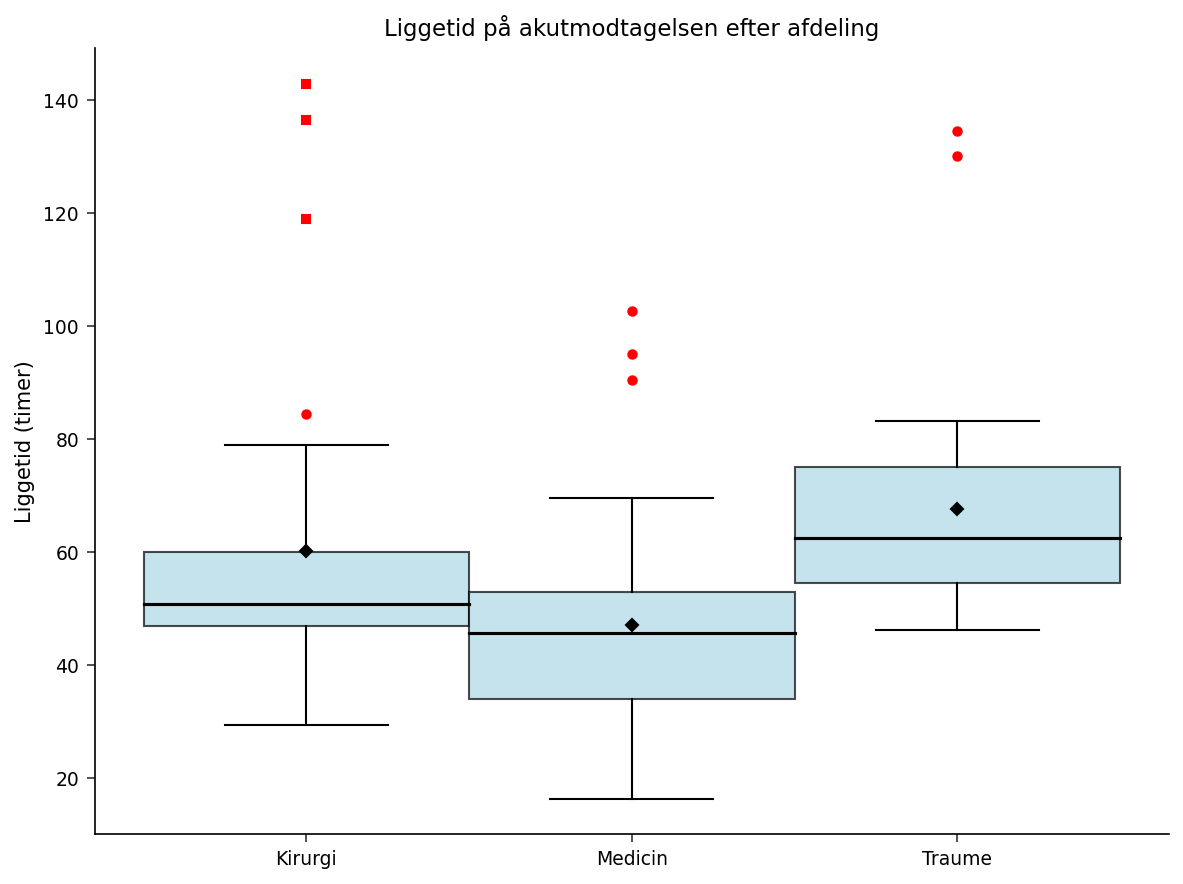

In [3]:
TITEL "Liggetid på akutmodtagelsen efter afdeling";
PROCEDURE boxplot data=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
KØR;

## Trin 4 — Overlejr en gennemsnitstrend-linje

For at tydeliggøre gradienten fra afdeling til afdeling tilføjer vi `BOXCONNECT=MEAN`. PROC BOXPLOT tegner så en forbindende linje gennem gennemsnittet af hver boks (rudemarkørerne), hvilket forvandler de tre separate fordelinger til én læsbar trend. Fordi afdelingerne er ordnet Medicine → Surgery → Trauma, opsummerer den stigende forbindelseslinje eskaleringen i den gennemsnitlige opholdstid i ét træk — et nyttigt signal til et driftsdashboard.

                 Liggetid på akutmodtagelsen efter afdeling - gennemsnitstrend                  

                 Liggetid på akutmodtagelsen efter afdeling - gennemsnitstrend

                                     The BOXPLOT Procedure

Schematic Plots for Liggetid (timer)

Afdeling              N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Kirurgi              36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicin              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Traume               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Liggetid på akutmodtagelsen efter afdeling - gennemsnitstrend.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


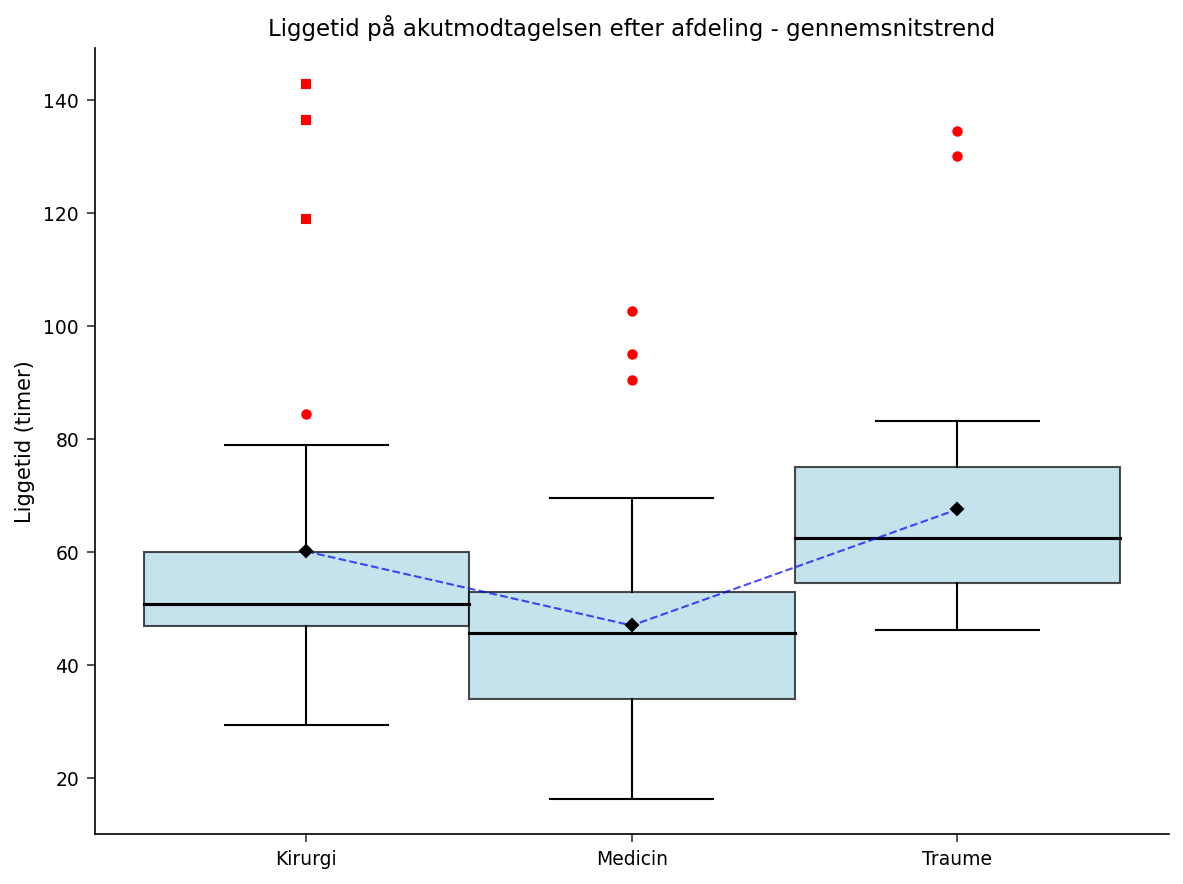

In [4]:
TITEL "Liggetid på akutmodtagelsen efter afdeling - gennemsnitstrend";
PROCEDURE boxplot data=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
KØR;

## Trin 5 — Vandret opstilling

Den samme sammenligning læses naturligt liggende. Ved at tilføje `HORIZONTAL` byttes akserne, så boksene løber fra venstre mod højre med responsen på x-aksen — en opstilling, der skalerer bedre, når afdelingsnavne er lange eller talrige, og som mange driftsdashboards foretrækker. Statistikkerne er identiske med den lodrette visning; kun orienteringen ændres.

                      Liggetid på akutmodtagelsen efter afdeling - vandret                      

                     Liggetid på akutmodtagelsen efter afdeling - vandret

                                     The BOXPLOT Procedure

Schematic Plots for Liggetid (timer)

Afdeling              N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Kirurgi              36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicin              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Traume               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Liggetid på akutmodtagelsen efter afdeling - vandret.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


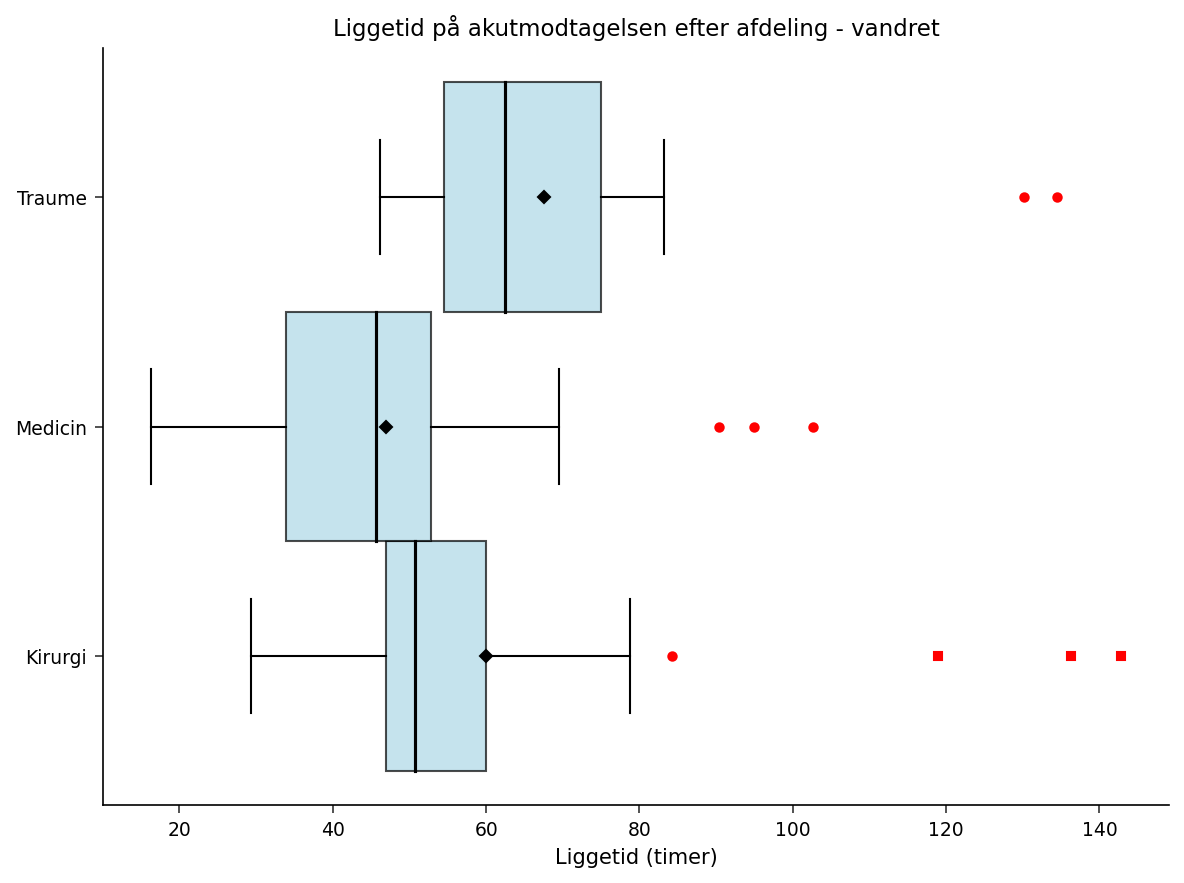

In [5]:
TITEL "Liggetid på akutmodtagelsen efter afdeling - vandret";
PROCEDURE boxplot data=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
KØR;

## Fortolkning af resultaterne

Boksplottene og den tilhørende statistiktabel oversætter de rå LOS-data til et driftsmæssigt handlingsanvisende billede:

- **En tydelig afdelingsgradient.** Medianopholdstiden stiger monotont på tværs af de tre afdelinger: **Medicine 40.0 t → Surgery 50.4 t → Trauma 60.5 t**. Gennemsnittene fortæller samme historie (41.6, 54.6, 62.8 t), og `BOXCONNECT=MEAN`-linjen i Trin 4 tegner denne eskalering som én stigende trend. Traume-patienter opholder sig i gennemsnit omkring 50 % længere end Medicine-patienter.

- **Variabiliteten betyder lige så meget som medianen.** Interkvartilafstanden (bokshøjden) er bredest for Medicine (Q1 32.8 t til Q3 51.2 t, en spredning på 18.3 timer) og smallest for Trauma (Q1 54.5 t til Q3 68.5 t, en spredning på 14.0 timer). Medicine er derfor ikke blot den korteste afdeling, men også den mindst forudsigelige — den egenskab, der vanskeliggør prognoser for sengestyring.

- **Outliers markerer de indlæggelsesafventende tilfælde.** De skematiske overskæg stopper ved 1.5 × IQR, så de tre røde punkter over Surgerys øvre overskæg (med top ved 84.3 t) skiller sig ud som ægte lange ophold — netop de indlæggelsesafventende tilfælde, der beslaglægger uforholdsmæssigt mange sengetimer. Medicine og Trauma viser ingen punkter uden for deres overskæg i denne stikprøve.

- **Spændvidden fortæller kapacitetsplanlægningens historie.** De observerede ophold spænder 16.3–69.5 t i Medicine, 29.3–84.3 t i Surgery og 46.1–83.2 t i Trauma. Trauma producerer aldrig et kort ophold (dets minimum på 46.1 t overstiger Medicines median), hvilket er, hvad et driftsteam ville forvente af den mest ressourcekrævende afdeling.

Tilsammen giver disse visninger en skadestueledelse et forsvarligt, fordelingsbevidst grundlag for bemanding og kapacitetsplanlægning — langt mere informativt end at sammenligne afdelingernes gennemsnitlige LOS alene.